# 📊 Retail Demand Analytics & Business Insights

### Big Data Analytics using Python, Pandas & SQL

---

## 📌 Project Overview

This project focuses on analyzing retail sales data to uncover actionable business insights across product categories, customer segments, and time-based trends.

Using Python and Pandas, the dataset is processed through a structured ETL pipeline—where raw data is cleaned, transformed, and aggregated to simulate Big Data concepts such as MapReduce on a manageable dataset.

The processed data is further stored in SQLite and analyzed to identify high-performing categories, customer purchasing behavior, and seasonal demand patterns. These insights support data-driven decision-making and strategic business planning.

---

## 🔍 Key Business Questions

* Which product categories generate the highest revenue?
* Which customer segments contribute most to overall sales?
* How do sales trends vary across different months and seasons?
* What purchasing patterns can be identified from customer behavior?

---

## ⚙️ Tools & Dataset

**Technologies Used:**

* Python (Data Processing & Analysis)
* Pandas (Data Cleaning & Aggregation)
* Matplotlib (Data Visualization)
* SQLite (Data Storage & Querying)

**Dataset:**
Retail Sales Dataset (Kaggle) — used as a structured subset to simulate Big Data analytics workflows.

---

## 📈 Key Highlights

* Processed and analyzed 300K+ retail records
* Applied GroupBy aggregations to simulate MapReduce logic
* Built an ETL pipeline (Extract → Transform → Load)
* Identified top-performing categories such as Electronics and Grocery
* Generated insights on customer segments and seasonal trends


In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [77]:
df = pd.read_csv('Retail Dataset(Roww).csv')
df.head()

,Country,Age,Gender,Customer_Segment,Date,Year,Month,Total_Purchases,Total_Amount,Product_Category,Product_Brand,Product_Type,Payment_Method
0,Germany,21.0,Male,Regular,9/18/2023,2023.0,September,3.0,324.086270,Clothing,Nike,Shorts,Debit Card
1,UK,19.0,Female,Premium,12/31/2023,2023.0,December,2.0,806.707815,Electronics,Samsung,Tablet,Credit Card
2,Australia,48.0,Male,Regular,4/26/2023,2023.0,April,3.0,1063.432799,Books,Penguin Books,Children's,Credit Card
3,Canada,56.0,Male,Premium,05-08-2023,2023.0,May,7.0,2466.854021,Home Decor,Home Depot,Tools,PayPal
4,UK,22.0,Male,Premium,01-10-2024,2024.0,January,2.0,248.553049,Grocery,Nestle,Chocolate,Cash


In [78]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Country           301739 non-null  object 
 1   Age               301837 non-null  float64
 2   Gender            301693 non-null  object 
 3   Customer_Segment  301795 non-null  object 
 4   Date              301651 non-null  object 
 5   Year              301660 non-null  float64
 6   Month             301737 non-null  object 
 7   Total_Purchases   301649 non-null  float64
 8   Total_Amount      301660 non-null  float64
 9   Product_Category  301727 non-null  object 
 10  Product_Brand     301729 non-null  object 
 11  Product_Type      302010 non-null  object 
 12  Payment_Method    301713 non-null  object 
dtypes: float64(4), object(9)
memory usage: 30.0+ MB


Country             271
Age                 173
Gender              317
Customer_Segment    215
Date                359
Year                350
Month               273
Total_Purchases     361
Total_Amount        350
Product_Category    283
Product_Brand       281
Product_Type          0
Payment_Method      297
dtype: int64

In [79]:
cat_cols = ['Country','Gender','Customer_Segment',
            'Product_Category','Product_Brand','Payment_Method']

df[cat_cols] = df[cat_cols].fillna('Unknown')

num_cols = ['Age','Total_Purchases','Total_Amount']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [80]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'] = df['Date'].ffill()


In [81]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

In [82]:
df['Avg_Order_Value'] = df['Total_Amount'] / df['Total_Purchases']

In [83]:
df['Total_Amount_M'] = df['Total_Amount'] / 1_000_000

In [84]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Country           302010 non-null  object        
 1   Age               302010 non-null  float64       
 2   Gender            302010 non-null  object        
 3   Customer_Segment  302010 non-null  object        
 4   Date              302010 non-null  datetime64[ns]
 5   Year              302010 non-null  int32         
 6   Month             302010 non-null  int32         
 7   Total_Purchases   302010 non-null  float64       
 8   Total_Amount      302010 non-null  float64       
 9   Product_Category  302010 non-null  object        
 10  Product_Brand     302010 non-null  object        
 11  Product_Type      302010 non-null  object        
 12  Payment_Method    302010 non-null  object        
 13  Month_Name        302010 non-null  object        
 14  Avg_

Country             0
Age                 0
Gender              0
Customer_Segment    0
Date                0
Year                0
Month               0
Total_Purchases     0
Total_Amount        0
Product_Category    0
Product_Brand       0
Product_Type        0
Payment_Method      0
Month_Name          0
Avg_Order_Value     0
Total_Amount_M      0
dtype: int64

In [85]:
conn = sqlite3.connect("retail.db")
df.to_sql("retail_data", conn, if_exists="replace", index=False)


302010

In [86]:
query1 = """
SELECT Product_Category,
ROUND(SUM(Total_Amount)/1000000,2) AS Total_M
FROM retail_data
WHERE Product_Category != 'Unknown'
GROUP BY Product_Category
"""

result = pd.read_sql(query, conn)
print(result)

  Product_Category  Total_M
0            Books    74.65
1         Clothing    74.89
2      Electronics    97.50
3          Grocery    91.16
4       Home Decor    74.35


In [87]:
total_sales = df['Total_Amount_M'].sum()
avg_order = df['Avg_Order_Value'].mean()
total_orders = df['Total_Purchases'].sum()

print("========== KPI SUMMARY ==========")
print(f"💰 Total Sales        : {total_sales:.2f} M")
print(f"🧾 Avg Order Value   : {avg_order:.2f}")
print(f"🛒 Total Purchases: {total_orders/1000:.1f}K")
print("=================================")

========== KPI SUMMARY ==========
💰 Total Sales        : 412.93 M
🧾 Avg Order Value   : 255.23
🛒 Total Purchases: 1618.6K


**Insight:** Strong total sales and high transaction volume indicate stable business performance, supported by consistent customer purchasing behavior.

###

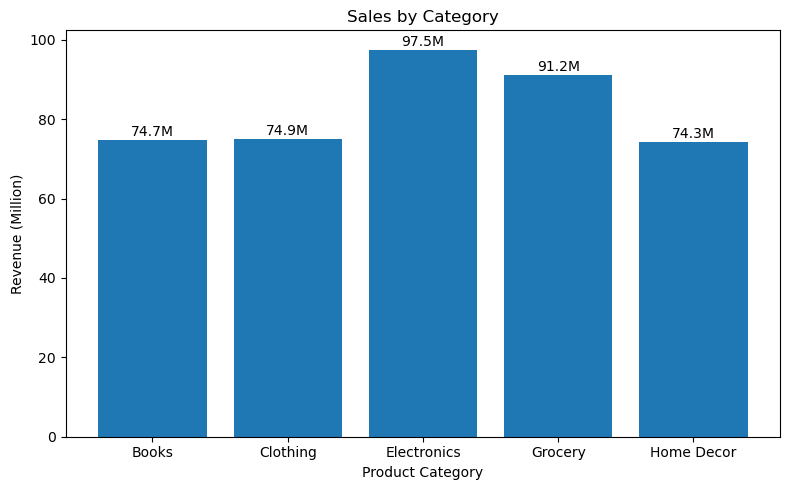

In [88]:
plt.figure(figsize=(8,5))

plt.bar(result['Product_Category'], result['Total_M'])

for i, v in enumerate(result['Total_M']):
    plt.text(i, v + 1, f"{v:.1f}M", ha='center')

plt.title("Sales by Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue (Million)")

plt.tight_layout()
plt.show()

**Insight:** Electronics leads sales, followed by Grocery, indicating strong demand for essential and high-value products. Other categories show balanced contribution.

###

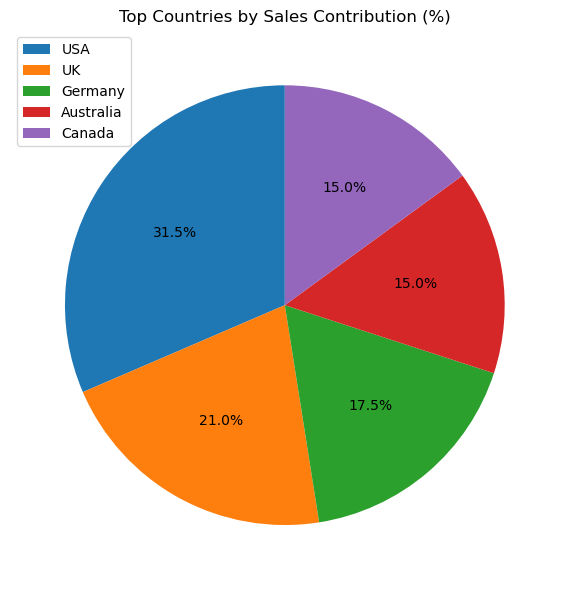

In [89]:
c = df.groupby('Country')['Total_Amount_M'].sum() \
      .drop('Unknown', errors='ignore') \
      .sort_values(ascending=False).head(5)

plt.figure(figsize=(6,6))

plt.pie(c,
        labels=None,               
        autopct='%1.1f%%',
        startangle=90)

plt.legend(c.index, loc='upper left')

plt.title('Top Countries by Sales Contribution (%)')

plt.tight_layout()
plt.show()

**Insight:** The USA dominates sales, with the UK and Germany also contributing significantly, highlighting key revenue-driving markets.

###

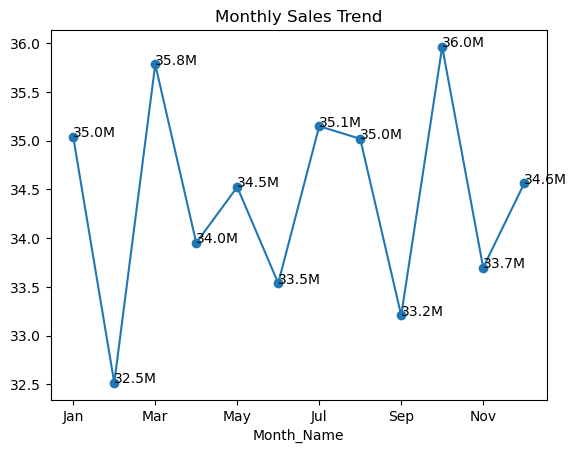

In [90]:
m = df.groupby('Month_Name')['Total_Amount_M'].sum()

order = ['Jan','Feb','Mar','Apr','May','Jun',
         'Jul','Aug','Sep','Oct','Nov','Dec']

ax = m.reindex(order).plot(marker='o')

for i, v in enumerate(m.reindex(order)):
    ax.text(i, v, f'{v:.1f}M')

plt.title('Monthly Sales Trend')
plt.show()

**Insight:** Sales fluctuate across months, suggesting seasonal patterns and opportunities for targeted promotions during low-performing periods.

###

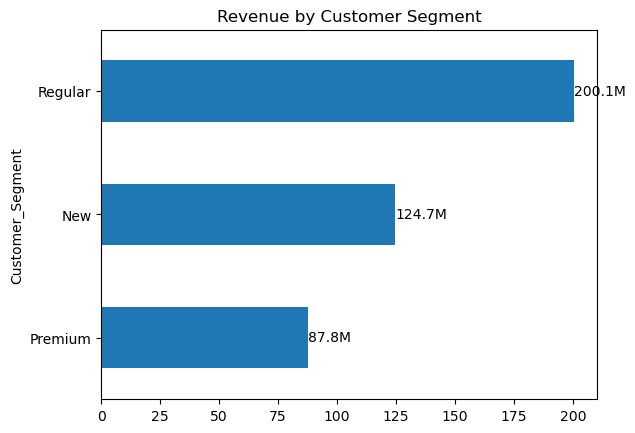

In [91]:
ax = df.groupby('Customer_Segment')['Total_Amount_M'].sum().drop('Unknown', errors='ignore') \
       .sort_values().plot(kind='barh')

ax.bar_label(ax.containers[0], fmt='%.1fM')
plt.title('Revenue by Customer Segment')
plt.show()

**Insight:** Regular customers contribute the highest revenue, indicating strong retention, while premium customers represent high-value potential.

###

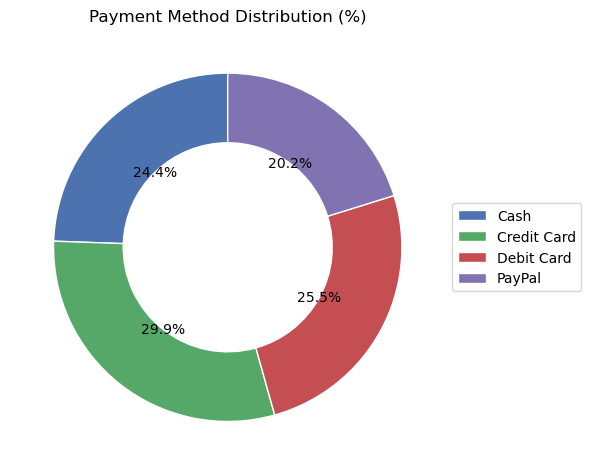

In [92]:
p = df.groupby('Payment_Method')['Total_Amount_M'].sum().drop('Unknown', errors='ignore')

plt.figure(figsize=(6,6))

plt.pie(p,
        labels=None,                    #
        autopct='%1.1f%%',
        startangle=90,
        colors=['#4C72B0','#55A868','#C44E52','#8172B2'],
        wedgeprops={'width':0.4, 'edgecolor':'white'})

plt.legend(p.index, loc='center left', bbox_to_anchor=(1, 0.5))

plt.title("Payment Method Distribution (%)")

plt.tight_layout()
plt.show()

**Insight:** Digital payments (Credit/Debit cards) dominate transactions, reflecting customer preference for convenience and secure payment methods.

###

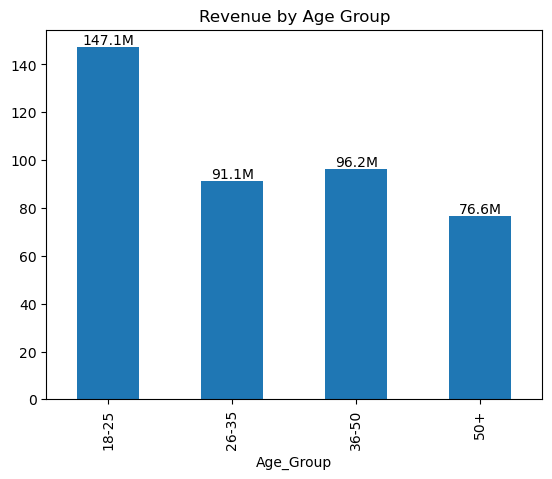

In [93]:
df['Age_Group'] = pd.cut(df['Age'], [18,25,35,50,70],
                         labels=['18-25','26-35','36-50','50+'])

ax = df.groupby('Age_Group', observed=True)['Total_Amount_M'].sum().plot(kind='bar')

ax.bar_label(ax.containers[0], fmt='%.1fM')
plt.title('Revenue by Age Group')
plt.show()

**Insight:** The 18–25 age group contributes the most sales, showing higher engagement among younger customers compared to older segments.

## 📌 Conclusion

This project demonstrates how Big Data analytics concepts can be applied to a manageable retail dataset using Python, Pandas, and SQLite through a structured ETL pipeline.

The analysis reveals that **Electronics (97.5M) and Grocery (91.2M)** are the top-performing product categories, contributing significantly to total revenue. Customer segmentation shows that **regular customers (200M+)** drive the majority of sales, indicating strong customer retention.

Age group analysis highlights that **18–25 customers contribute the highest revenue**, showing higher engagement among younger users. Additionally, monthly sales trends indicate **seasonal fluctuations**, with peak sales around October and lower performance in September.

Payment analysis shows a clear preference for **digital methods (Credit/Debit cards)** over cash, reflecting modern customer behavior.

Overall, the project highlights how data-driven insights can help businesses optimize product strategy, target high-value customers, and improve decision-making.